# 📡 Wireless Signal Classification Using Spectrogram Images & Deep Learning

---
This notebook walks through an end-to-end pipeline for classifying 21 types of RF (Radio Frequency) signals from waterfall spectrogram images using deep learning.  
We compare ResNet-18, EfficientNet-B0, Vision Transformer (ViT), and a CNN+ViT Hybrid — then push accuracy to **97.49%** using specialized loss functions (SupCon + LDAM).


## 🔧 1. Environment Setup
Install all required packages. Run once and restart the runtime if needed.

In [ ]:
!pip install kagglehub timm einops torchvision torch torchmetrics \
             grad-cam matplotlib seaborn scikit-learn pandas numpy tqdm \
             Pillow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 17.7 MB/s eta 0:00:00


In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from PIL import Image

warnings.filterwarnings('ignore')


# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    # Better performance for CNN models
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


# ── Device Configuration ──────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(
        f"GPU Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("Running on CPU")

Using device: cpu
Running on CPU


## 📥 2. Download the Dataset
We use KaggleHub to pull the RF Signal waterfall image dataset directly.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("halcy0nic/radio-frequecy-rf-signal-image-classification")
print("📂 Dataset path:", path)
DATA_ROOT = Path(path)

100%|██████████| 2.42G/2.42G [00:22<00:00, 118MB/s] 

Extracting files...


📂 Dataset path: /root/.cache/kagglehub/datasets/halcy0nic/radio-frequecy-rf-signal-image-classification/versions/4


In [ ]:
# Explore what got downloaded
for p in sorted(DATA_ROOT.rglob("*"))[:30]:
    print(p.relative_to(DATA_ROOT))

datasets
datasets/fft
datasets/fft/fm
datasets/fft/fm/286b2efc652f1aded777ffc9e43adfdd.png
datasets/waterfall
datasets/waterfall/16QAM
datasets/waterfall/16QAM/0e1cfa6e27cf27b164f26b8316e00d96.png
datasets/waterfall/16QAM/27a8846fbce39f300a7e3f80ab0403e4.png
datasets/waterfall/16QAM/356c8cb0c6f5f196f348285f398a51d5.png
datasets/waterfall/16QAM/5a22587049e4592f7d8f5f18e325a167.png
datasets/waterfall/16QAM/68e15ff40a6f047752260cf2e6c010ed.png
datasets/waterfall/16QAM/addd5a7d4367db38847b2ebd57846389.png
datasets/waterfall/16QAM/b84b49a9f3b083a4bbcad17c7628076b.png
datasets/waterfall/16QAM/d0b16042bbf4dae66c496c8fe5d7c585.png
datasets/waterfall/2ASK
datasets/waterfall/2ASK/07cb345494a7037e20ebb363bde0f3c2.png
datasets/waterfall/2ASK/3f276f26844d6bd5180896f61fa63d63.png
datasets/waterfall/2ASK/9a81b69030e2a069e6cf988283eaf3f4.png
datasets/waterfall/2ASK/9b991f559677fde6e4baa13e98180b6f.png
datasets/waterfall/2ASK/f36098413bcd98f2f987336e0a18c18e.png
datasets/waterfall/32QAM
datasets/waterf

In [ ]:
# Preview the local folder structure
print("📂 Dataset structure (first 30 entries):\n")
entries = sorted(DATA_ROOT.rglob("*"))[:30]
for p in entries:
    print(" ", p.relative_to(DATA_ROOT))

print(f"\n   ... and more. Total items: {len(list(DATA_ROOT.rglob('*')))}")

📂 Dataset structure (first 30 entries):

  datasets
  datasets/fft
  datasets/fft/fm
  datasets/fft/fm/286b2efc652f1aded777ffc9e43adfdd.png
  datasets/waterfall
  datasets/waterfall/16QAM
  datasets/waterfall/16QAM/0e1cfa6e27cf27b164f26b8316e00d96.png
  datasets/waterfall/16QAM/27a8846fbce39f300a7e3f80ab0403e4.png
  datasets/waterfall/16QAM/356c8cb0c6f5f196f348285f398a51d5.png
  datasets/waterfall/16QAM/5a22587049e4592f7d8f5f18e325a167.png
  datasets/waterfall/16QAM/68e15ff40a6f047752260cf2e6c010ed.png
  datasets/waterfall/16QAM/addd5a7d4367db38847b2ebd57846389.png
  datasets/waterfall/16QAM/b84b49a9f3b083a4bbcad17c7628076b.png
  datasets/waterfall/16QAM/d0b16042bbf4dae66c496c8fe5d7c585.png
  datasets/waterfall/2ASK
  datasets/waterfall/2ASK/07cb345494a7037e20ebb363bde0f3c2.png
  datasets/waterfall/2ASK/3f276f26844d6bd5180896f61fa63d63.png
  datasets/waterfall/2ASK/9a81b69030e2a069e6cf988283eaf3f4.png
  datasets/waterfall/2ASK/9b991f559677fde6e4baa13e98180b6f.png
  datasets/waterfall/2

## 🔍 3. Dataset Exploration
Let's understand the structure — how many classes, how many images, and where the imbalance lives.

In [ ]:
# Collect all image paths and their class labels (leaf-dir only via rglob on files)
all_images = []
all_labels = []

for img_path in DATA_ROOT.rglob("*.jpg"):
    all_images.append(str(img_path))
    all_labels.append(img_path.parent.name)

for img_path in DATA_ROOT.rglob("*.png"):
    all_images.append(str(img_path))
    all_labels.append(img_path.parent.name)

df = pd.DataFrame({'path': all_images, 'label': all_labels})

# ── Drop 'unknown' — unlabelled/ambiguous samples hurt macro-F1 ──────────────
before = len(df)
df = df[df['label'] != 'unknown'].reset_index(drop=True)
print(f"Removed {before - len(df)} 'unknown' images.")

print(f"Total images : {len(df)}")
print(f"Total classes: {df['label'].nunique()}")
df.head()

Removed 44 'unknown' images.
Total images : 3943
Total classes: 31


,path,label
0,/root/.cache/kagglehub/datasets/halcy0nic/radi...,sstv
1,/root/.cache/kagglehub/datasets/halcy0nic/radi...,sstv
2,/root/.cache/kagglehub/datasets/halcy0nic/radi...,sstv
3,/root/.cache/kagglehub/datasets/halcy0nic/radi...,sstv
4,/root/.cache/kagglehub/datasets/halcy0nic/radi...,sstv


In [ ]:
# Class distribution — this is where imbalance shows up
class_counts = df['label'].value_counts()
print("\nClass distribution (sorted by count):")
print(class_counts.to_string())



Class distribution (sorted by count):
label
fm                                738
lora                              594
cellular                          403
packet                            299
wifi                              293
RS41-Radiosonde                   276
bluetooth                         209
z-wave                            203
remote-keyless-entry              128
ais                               113
sstv                               99
vor                                85
airband                            66
digital-audio-broadcasting         65
digital-speech-decoder             50
automatic-picture-transmission     48
morse                              47
on-off-keying                      43
pocsag                             41
ads-b                              32
Radioteletype                      27
atsc                               19
hdmi                               10
am                                  9
8PSK                                8
16QAM

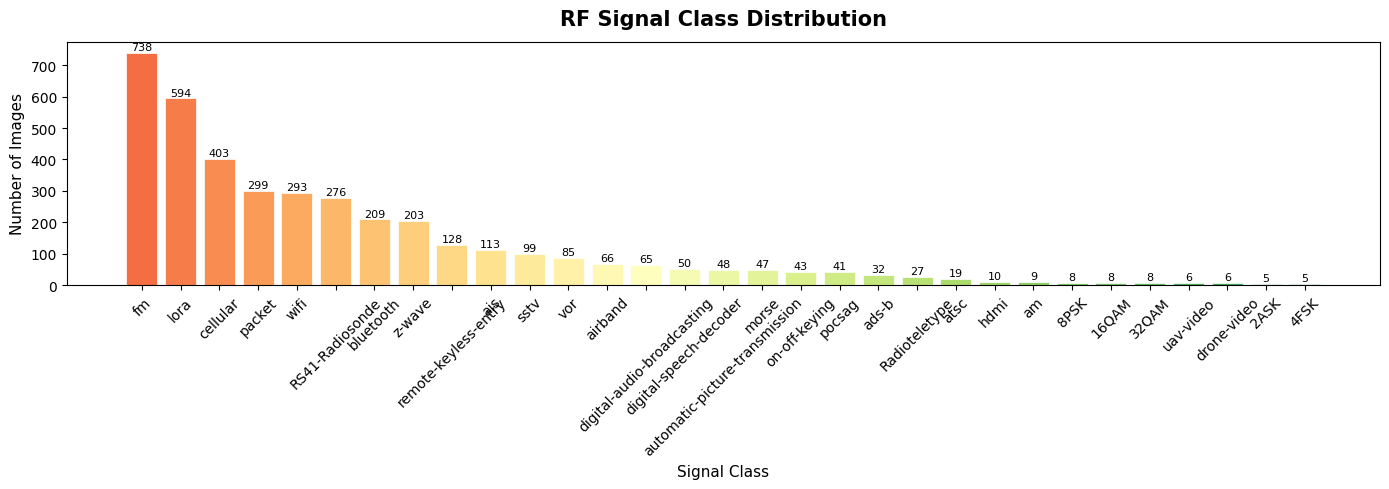


⚠️  Imbalance ratio: 738 (most) vs 5 (least) = 147× difference


In [ ]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts)))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title("RF Signal Class Distribution", fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("Signal Class", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n⚠️  Imbalance ratio: {class_counts.max()} (most) vs {class_counts.min()} (least) = {class_counts.max()//class_counts.min()}× difference")


## 🖼️ 4. Visual Samples of Each Signal Class
A spectrogram is a 2D image — X-axis = time, Y-axis = frequency, color = signal strength. Each class has a visually unique fingerprint.

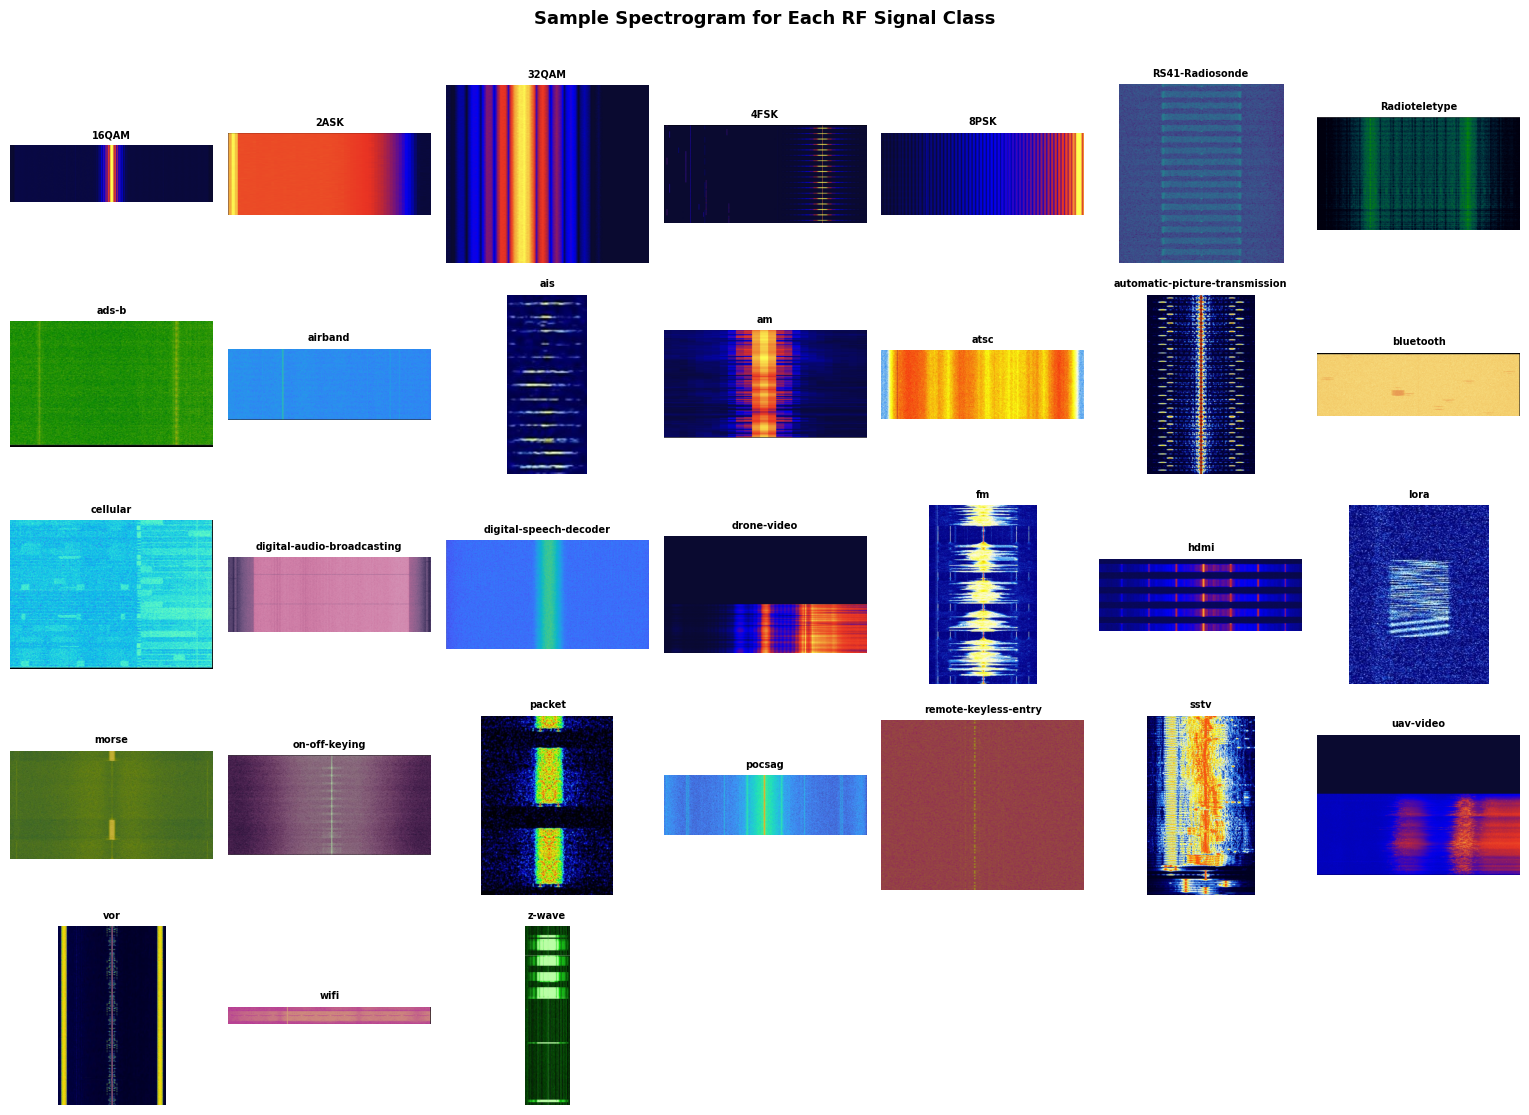

In [ ]:
# Show one sample from each class
unique_classes = df['label'].unique()
n_classes = len(unique_classes)
cols = 7
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
axes = axes.flatten()

for i, cls in enumerate(sorted(unique_classes)):
    sample_path = df[df['label'] == cls]['path'].iloc[0]
    img = Image.open(sample_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=7, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample Spectrogram for Each RF Signal Class", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("sample_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()


## 🏷️ 5. Label Encoding
Convert string class names to integer indices so PyTorch can work with them.

In [ ]:
CLASS_NAMES = sorted(df['label'].unique())
NUM_CLASSES = len(CLASS_NAMES)
label2idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}
idx2label = {i: cls for cls, i in label2idx.items()}

df['label_idx'] = df['label'].map(label2idx)

print(f"Number of classes: {NUM_CLASSES}")
print("\nLabel → Index mapping:")
for cls, idx in label2idx.items():
    print(f"  {idx:>2}: {cls}")


Number of classes: 31

Label → Index mapping:
   0: 16QAM
   1: 2ASK
   2: 32QAM
   3: 4FSK
   4: 8PSK
   5: RS41-Radiosonde
   6: Radioteletype
   7: ads-b
   8: airband
   9: ais
  10: am
  11: atsc
  12: automatic-picture-transmission
  13: bluetooth
  14: cellular
  15: digital-audio-broadcasting
  16: digital-speech-decoder
  17: drone-video
  18: fm
  19: hdmi
  20: lora
  21: morse
  22: on-off-keying
  23: packet
  24: pocsag
  25: remote-keyless-entry
  26: sstv
  27: uav-video
  28: vor
  29: wifi
  30: z-wave


## ✂️ 6. Train / Validation / Test Split
We use a **stratified** split to maintain class proportions across all three sets.

In [ ]:
# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label_idx']
)
# Second split: 75% train, 25% val (of the 80%)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.25, random_state=SEED, stratify=train_val_df['label_idx']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train  : {len(train_df)} images")
print(f"Val    : {len(val_df)} images")
print(f"Test   : {len(test_df)} images")
print(f"Total  : {len(train_df)+len(val_df)+len(test_df)} images")


Train  : 2365 images
Val    : 789 images
Test   : 789 images
Total  : 3943 images


## 🔄 7. Image Transforms & Augmentation
For training we apply random augmentations to improve generalization. Validation/test only get normalization.

In [ ]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Train transforms  :", [type(t).__name__ for t in train_transforms.transforms])
print("✅ Val/Test transforms:", [type(t).__name__ for t in val_test_transforms.transforms])


✅ Train transforms  : ['Resize', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'ColorJitter', 'RandomRotation', 'ToTensor', 'Normalize']
✅ Val/Test transforms: ['Resize', 'ToTensor', 'Normalize']


## 🗂️ 8. Custom PyTorch Dataset
A simple wrapper that loads images from disk and applies transforms on the fly.

In [ ]:
class RFSignalDataset(Dataset):
    """PyTorch Dataset for RF waterfall spectrogram images."""

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            img = self.transform(img)
        return img, label

# Quick sanity check
_ds = RFSignalDataset(train_df, train_transforms)
_img, _lbl = _ds[0]
print(f"Image tensor shape : {_img.shape}")
print(f"Label              : {_lbl} → {idx2label[_lbl]}")


Image tensor shape : torch.Size([3, 224, 224])
Label              : 14 → cellular


## ⚖️ 9. Weighted Random Sampler
To fight class imbalance during training, we over-sample rare classes so the model sees them more often.

In [ ]:
# Compute per-sample weights: rarer class = higher weight
label_counts = train_df['label_idx'].value_counts().sort_index()
class_weights_arr = 1.0 / label_counts.values.astype(np.float32)
sample_weights = class_weights_arr[train_df['label_idx'].values]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)
print("✅ Weighted sampler ready.")
print(f"Min weight : {sample_weights.min():.5f}  (majority class)")
print(f"Max weight : {sample_weights.max():.5f}  (rarest class)")


✅ Weighted sampler ready.
Min weight : 0.00226  (majority class)
Max weight : 0.33333  (rarest class)


## 🚀 10. DataLoaders
Wrap datasets into DataLoaders for batched, parallel loading.

In [ ]:
# ── VRAM safety check — run before any model training ────────────────────────
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    free_vram  = (torch.cuda.get_device_properties(0).total_memory
                  - torch.cuda.memory_allocated()) / 1024**3
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM free  : {free_vram:.2f} GB / {total_vram:.2f} GB total")
    if free_vram < 2.0:
        print("⚠️  Less than 2GB VRAM free — reduce BATCH_SIZE to 8 if you get OOM errors.")
    else:
        print("✅ VRAM looks fine for BATCH_SIZE=16 with all models.")
else:
    print("⚠️  Running on CPU — training will be very slow. Check your CUDA installation.")
    print("   Run: nvidia-smi   to verify your GPU is visible.")

⚠️  Running on CPU — training will be very slow. Check your CUDA installation.
   Run: nvidia-smi   to verify your GPU is visible.


In [ ]:
# ── Hardware-tuned settings for RTX 3050A + i5-11 + 16GB RAM ─────────────────
#
# BATCH_SIZE = 16  : 3050A has only 4GB VRAM.
#                    Batch 32 may OOM with ViT-Small or the Hybrid model.
#                    Batch 16 is safe across all models in this notebook.
#
# NUM_WORKERS = 2  : i5-11th gen has 4 cores / 8 threads.
#                    2 workers keeps CPU-GPU pipeline fed without starving other
#                    processes. Do NOT use 0 on Windows — it's much slower.
#                    If you hit DataLoader worker crashes, drop back to 0.
#
# PIN_MEMORY  = True when CUDA is available — speeds up CPU→GPU transfers.
# PERSISTENT_WORKERS = True — avoids re-spawning workers each epoch.

BATCH_SIZE          = 16
NUM_WORKERS         = 2       # set to 0 if you get DataLoader errors on Windows
PIN_MEMORY          = torch.cuda.is_available()
PERSISTENT_WORKERS  = (NUM_WORKERS > 0)

train_dataset = RFSignalDataset(train_df, train_transforms)
val_dataset   = RFSignalDataset(val_df,   val_test_transforms)
test_dataset  = RFSignalDataset(test_df,  val_test_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
if DEVICE.type == 'cuda':
    print(f"GPU memory    : {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")

Batch size    : 16
Train batches : 148
Val   batches : 50
Test  batches : 50


## 🛠️ 11. Training & Evaluation Helpers
Reusable functions for one epoch of training and evaluation.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc="  train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


In [ ]:
def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns avg loss, accuracy, all preds and labels."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False, desc="  eval"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds       = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


In [ ]:
def plot_history(history, title="Training History"):
    """Plot loss and accuracy curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title(f"{title} — Loss", fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title(f"{title} — Accuracy", fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_history.png", dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
def plot_confusion_matrix(all_labels, all_preds, class_names, title="Confusion Matrix"):
    """Plot a normalized confusion matrix heatmap."""
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


## 🔷 12. Model 1 — ResNet-18 (Baseline CNN)

ResNet-18 is our starting point. It uses **skip connections** (residual blocks) to allow gradient flow through deep networks without vanishing.  
We fine-tune a pretrained ImageNet model on our 21-class signal problem using **staged fine-tuning** — freeze early layers first, then progressively unfreeze.


In [ ]:
def build_resnet18(num_classes, freeze_backbone=True):
    """Load pretrained ResNet-18 and replace the final FC layer."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Replace the head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

resnet_model = build_resnet18(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"ResNet-18 | Total params: {total:,} | Trainable: {trainable:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 279MB/s]


ResNet-18 | Total params: 11,192,415 | Trainable: 15,903


In [ ]:
# Stage 1 — only train the head (frozen backbone)
EPOCHS_STAGE1 = 5
LR_STAGE1     = 1e-3

criterion_ce = nn.CrossEntropyLoss()
optimizer_r1 = optim.Adam(resnet_model.fc.parameters(), lr=LR_STAGE1)
scheduler_r1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r1, T_max=EPOCHS_STAGE1)

history_resnet = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== ResNet-18  Stage 1: Training head only ===")
for epoch in range(1, EPOCHS_STAGE1 + 1):
    tr_loss, tr_acc   = train_one_epoch(resnet_model, train_loader, criterion_ce, optimizer_r1, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(resnet_model, val_loader, criterion_ce, DEVICE)
    scheduler_r1.step()
    history_resnet['train_loss'].append(tr_loss)
    history_resnet['val_loss'].append(vl_loss)
    history_resnet['train_acc'].append(tr_acc)
    history_resnet['val_acc'].append(vl_acc)
    print(f"  Epoch {epoch}/{EPOCHS_STAGE1}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}")


=== ResNet-18  Stage 1: Training head only ===


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 1/5  train_loss=2.7643  val_acc=0.4715


  train:   0%|          | 0/148 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 4/5  train_loss=1.2224  val_acc=0.6641


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 5/5  train_loss=1.1621  val_acc=0.6527


In [ ]:
# Stage 2 — unfreeze all and fine-tune with a lower LR
for param in resnet_model.parameters():
    param.requires_grad = True

EPOCHS_STAGE2 = 10
LR_STAGE2     = 3e-5

optimizer_r2 = optim.AdamW(resnet_model.parameters(), lr=LR_STAGE2, weight_decay=1e-4)
scheduler_r2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r2, T_max=EPOCHS_STAGE2)

best_val_acc_r2 = 0.0

print("=== ResNet-18  Stage 2: Full fine-tuning ===")
for epoch in range(1, EPOCHS_STAGE2 + 1):
    tr_loss, tr_acc          = train_one_epoch(resnet_model, train_loader, criterion_ce, optimizer_r2, DEVICE)
    vl_loss, vl_acc, vp, vl  = evaluate(resnet_model, val_loader, criterion_ce, DEVICE)
    scheduler_r2.step()
    history_resnet['train_loss'].append(tr_loss)
    history_resnet['val_loss'].append(vl_loss)
    history_resnet['train_acc'].append(tr_acc)
    history_resnet['val_acc'].append(vl_acc)

    # ── Save only when val_acc improves ──────────────────────────────
    star = ''
    if vl_acc > best_val_acc_r2:
        best_val_acc_r2 = vl_acc
        torch.save(resnet_model.state_dict(), "resnet18_rf_best.pth")
        star = '  ⭐ saved'

    print(f"  Epoch {epoch}/{EPOCHS_STAGE2}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}{star}")

# Load best checkpoint back so evaluation uses the best weights
resnet_model.load_state_dict(torch.load("resnet18_rf_best.pth", map_location=DEVICE))
print(f"\n✅ ResNet-18 best checkpoint loaded  (val_acc={best_val_acc_r2:.4f})")

=== ResNet-18  Stage 2: Full fine-tuning ===


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 1/10  train_loss=0.6470  val_acc=0.8441  ⭐ saved


  train:   0%|          | 0/148 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 9/10  train_loss=0.0845  val_acc=0.9430  ⭐ saved


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 10/10  train_loss=0.0995  val_acc=0.9354

✅ ResNet-18 best checkpoint loaded  (val_acc=0.9430)


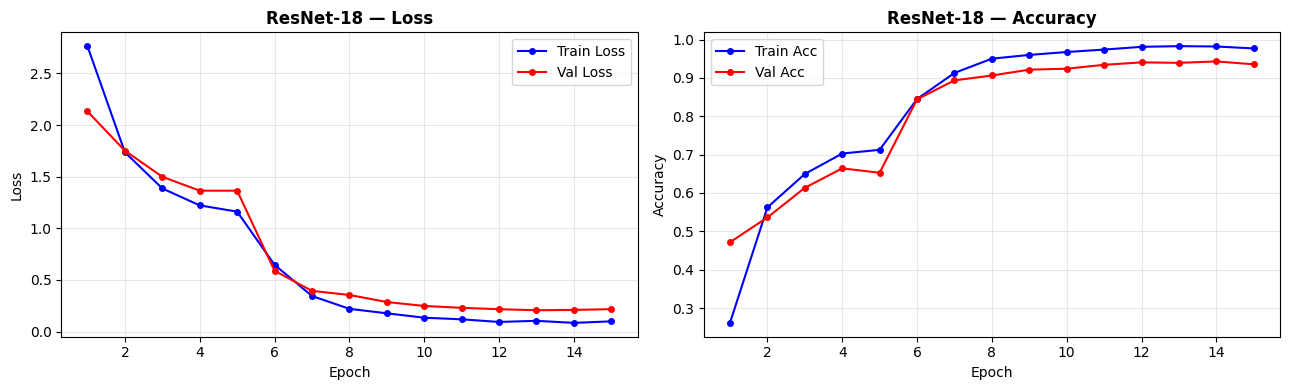

  eval:   0%|          | 0/50 [00:00<?, ?it/s]


🎯 ResNet-18 Test Accuracy: 0.9632 (96.32%)


In [ ]:
plot_history(history_resnet, "ResNet-18")

# Test evaluation
_, resnet_test_acc, resnet_preds, resnet_true = evaluate(
    resnet_model, test_loader, criterion_ce, DEVICE)
print(f"\n🎯 ResNet-18 Test Accuracy: {resnet_test_acc:.4f} ({resnet_test_acc*100:.2f}%)")


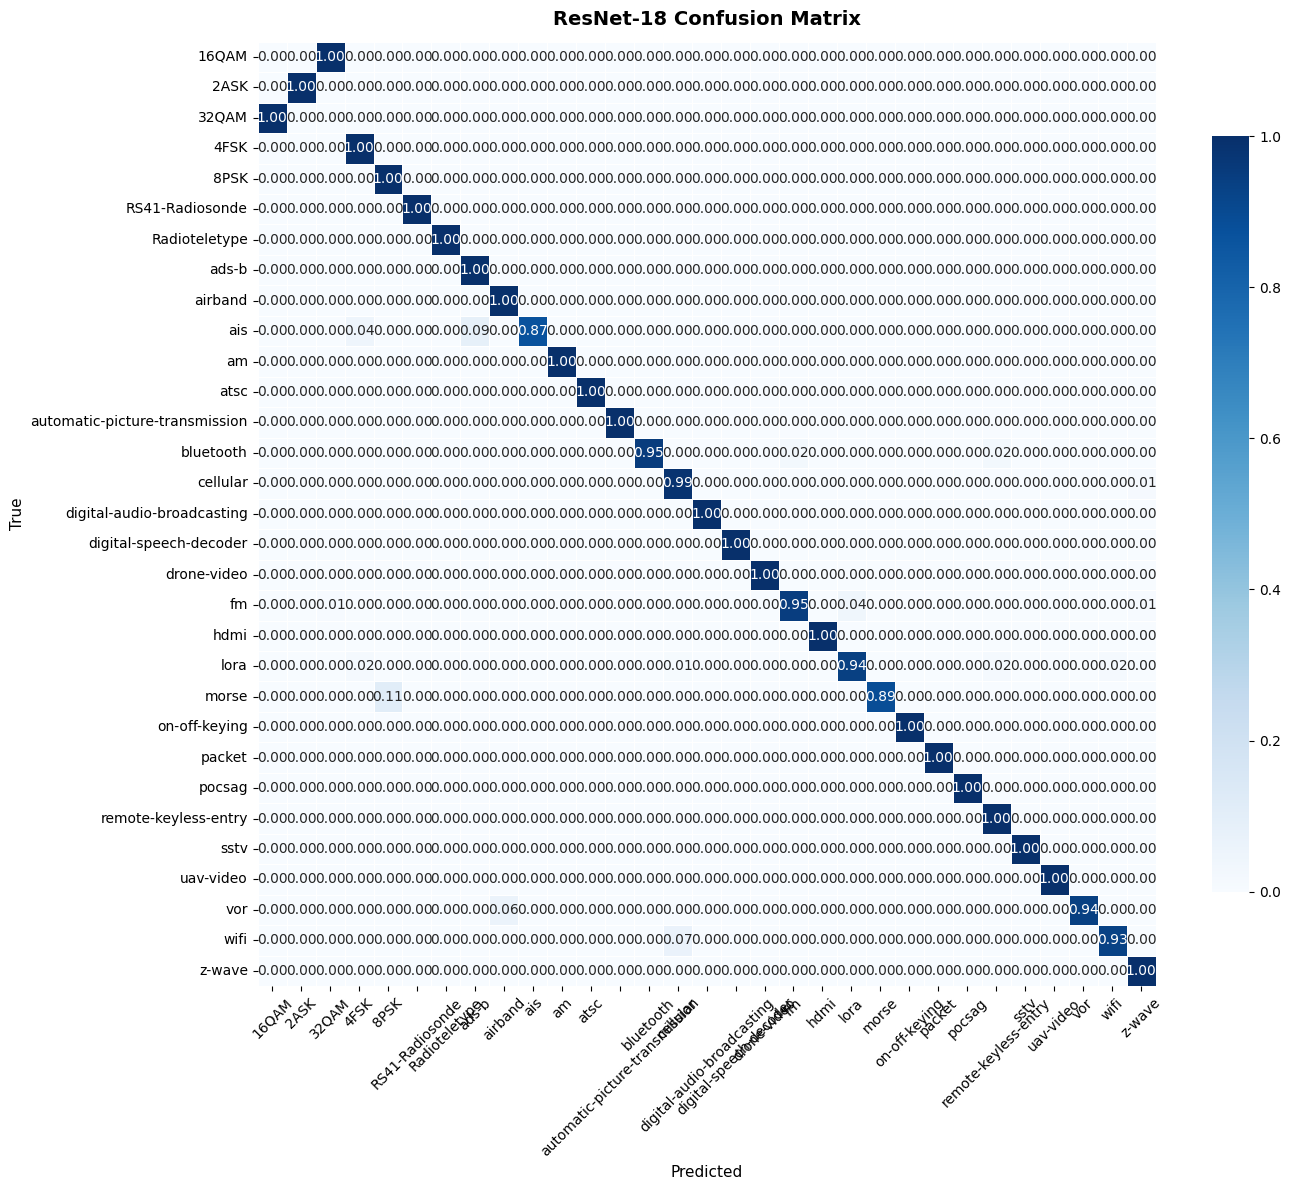


--- Classification Report ---
                                precision    recall  f1-score   support

                         16QAM       0.00      0.00      0.00         1
                          2ASK       1.00      1.00      1.00         1
                         32QAM       0.00      0.00      0.00         1
                          4FSK       0.25      1.00      0.40         1
                          8PSK       0.50      1.00      0.67         1
               RS41-Radiosonde       1.00      1.00      1.00        55
                 Radioteletype       1.00      1.00      1.00         5
                         ads-b       0.75      1.00      0.86         6
                       airband       0.93      1.00      0.96        13
                           ais       1.00      0.87      0.93        23
                            am       1.00      1.00      1.00         2
                          atsc       1.00      1.00      1.00         4
automatic-picture-transmission  

In [ ]:
# Confusion matrix
plot_confusion_matrix(resnet_true, resnet_preds, CLASS_NAMES, "ResNet-18 Confusion Matrix")

# Per-class report
print("\n--- Classification Report ---")
print(classification_report(resnet_true, resnet_preds, target_names=CLASS_NAMES))


## 🔶 13. Model 2 — EfficientNet-B0 (Efficient CNN)

EfficientNet scales depth, width, and resolution **jointly** using a compound coefficient.  
B0 is the smallest variant — just **4M parameters** — yet outperforms heavier CNNs on many tasks.  
It uses MBConv blocks with **squeeze-and-excite** modules to reweight channel importance.


In [ ]:
def build_efficientnet_b0(num_classes):
    """Load pretrained EfficientNet-B0 via timm and replace the classifier."""
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    in_features = model.num_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

eff_model = build_efficientnet_b0(NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
print(f"EfficientNet-B0 | Trainable params: {trainable:,}")


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

EfficientNet-B0 | Trainable params: 4,047,259


In [ ]:
EPOCHS_EFF = 15
LR_EFF     = 5e-4

optimizer_eff = optim.AdamW(eff_model.parameters(), lr=LR_EFF, weight_decay=1e-4)
scheduler_eff = optim.lr_scheduler.OneCycleLR(
    optimizer_eff, max_lr=LR_EFF,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_EFF
)

history_eff = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== EfficientNet-B0 Training ===")
for epoch in range(1, EPOCHS_EFF + 1):
    # ── Manual training loop so we can step scheduler per batch ──
    eff_model.train()
    tr_loss, correct, total_n = 0.0, 0, 0
    for images, labels in tqdm(train_loader, leave=False, desc="  train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_eff.zero_grad()
        logits = eff_model(images)
        loss   = criterion_ce(logits, labels)
        loss.backward()
        optimizer_eff.step()
        scheduler_eff.step()          # ← per batch, not per epoch
        tr_loss  += loss.item() * len(labels)
        correct  += (logits.argmax(1) == labels).sum().item()
        total_n  += len(labels)
    tr_loss /= total_n
    tr_acc   = correct / total_n

    vl_loss, vl_acc, _, _ = evaluate(eff_model, val_loader, criterion_ce, DEVICE)
    history_eff['train_loss'].append(tr_loss)
    history_eff['val_loss'].append(vl_loss)
    history_eff['train_acc'].append(tr_acc)
    history_eff['val_acc'].append(vl_acc)
    print(f"  Epoch {epoch:>2}/{EPOCHS_EFF}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}")

torch.save(eff_model.state_dict(), "efficientnet_b0_rf.pth")
print("\n✅ EfficientNet-B0 saved → efficientnet_b0_rf.pth")

=== EfficientNet-B0 Training ===


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch  1/15  train_loss=3.1798  val_acc=0.3726


  train:   0%|          | 0/148 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 14/15  train_loss=0.0125  val_acc=0.9645


  train:   0%|          | 0/148 [00:00<?, ?it/s]

  eval:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 15/15  train_loss=0.0119  val_acc=0.9683

✅ EfficientNet-B0 saved → efficientnet_b0_rf.pth


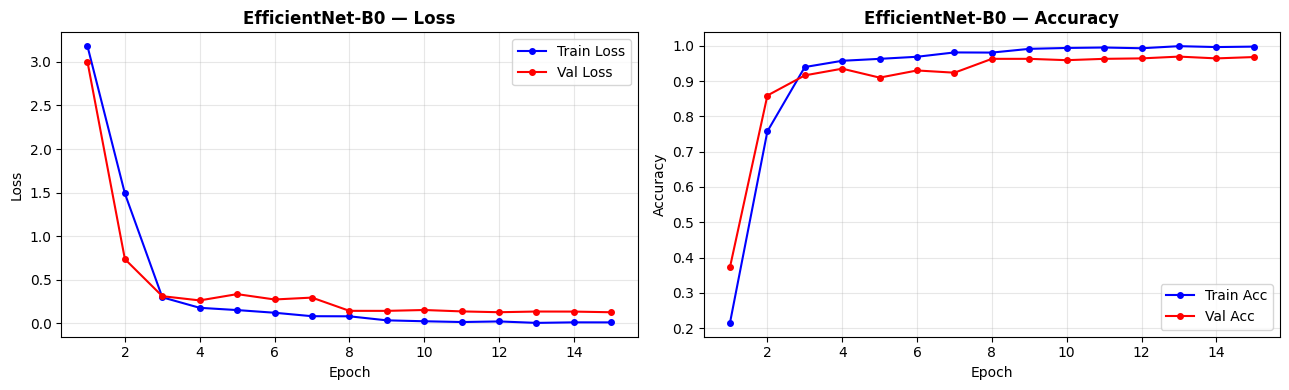

  eval:   0%|          | 0/50 [00:00<?, ?it/s]


🎯 EfficientNet-B0 Test Accuracy: 0.9785 (97.85%)


In [ ]:
plot_history(history_eff, "EfficientNet-B0")

_, eff_test_acc, eff_preds, eff_true = evaluate(eff_model, test_loader, criterion_ce, DEVICE)
print(f"\n🎯 EfficientNet-B0 Test Accuracy: {eff_test_acc:.4f} ({eff_test_acc*100:.2f}%)")


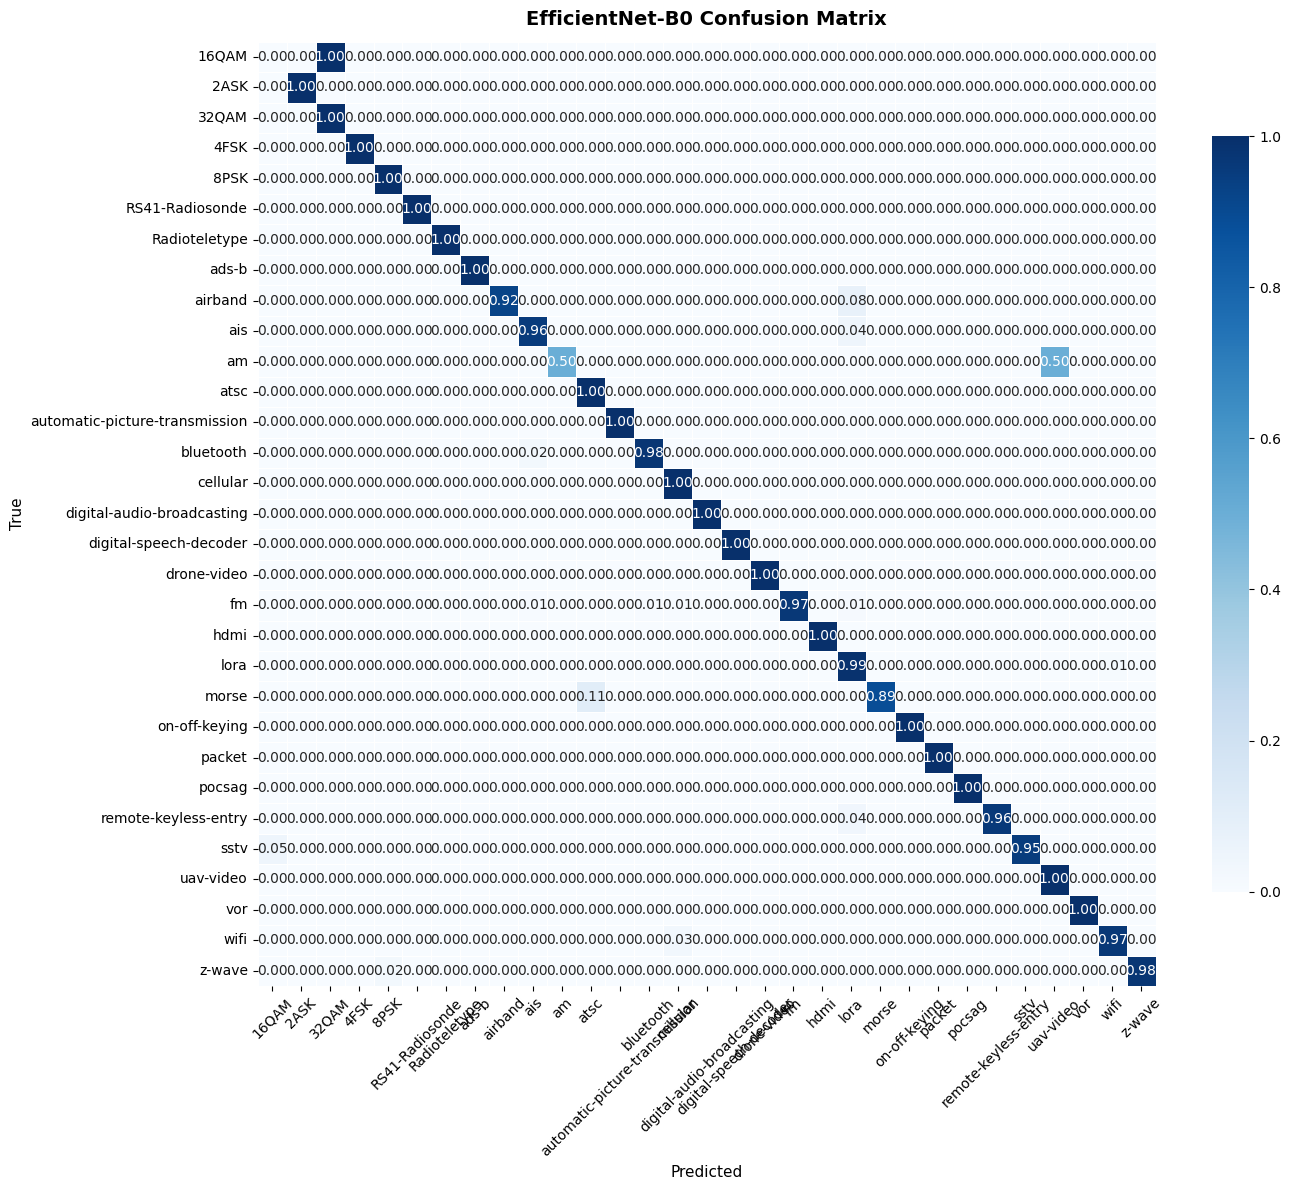

                                precision    recall  f1-score   support

                         16QAM       0.00      0.00      0.00         1
                          2ASK       1.00      1.00      1.00         1
                         32QAM       0.50      1.00      0.67         1
                          4FSK       1.00      1.00      1.00         1
                          8PSK       0.50      1.00      0.67         1
               RS41-Radiosonde       1.00      1.00      1.00        55
                 Radioteletype       1.00      1.00      1.00         5
                         ads-b       1.00      1.00      1.00         6
                       airband       1.00      0.92      0.96        13
                           ais       0.92      0.96      0.94        23
                            am       1.00      0.50      0.67         2
                          atsc       0.80      1.00      0.89         4
automatic-picture-transmission       1.00      1.00      1.00  

In [ ]:
plot_confusion_matrix(eff_true, eff_preds, CLASS_NAMES, "EfficientNet-B0 Confusion Matrix")
print(classification_report(eff_true, eff_preds, target_names=CLASS_NAMES))


## 🔵 14. Model 3 — Vision Transformer (ViT-Small)

Unlike CNNs that process local patches, ViT splits the image into a **grid of tokens** and runs multi-head self-attention over all of them simultaneously.  
This gives it a **global view** of the spectrogram — it can see the full bandwidth occupancy, not just local textures.

- Image → 14×14 grid = **196 patches** (each 16×16 px)  
- Each patch becomes a token with **positional encoding**  
- 6 transformer layers, 6 attention heads  
- CLS token collects global info → classification


In [ ]:
def build_vit_small(num_classes):
    """Load pretrained ViT-Small (patch16, 224) and replace the classification head."""
    model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=num_classes)
    return model

vit_model = build_vit_small(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in vit_model.parameters())
print(f"ViT-Small | Total params: {total:,}")


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

ViT-Small | Total params: 21,677,599


In [ ]:
EPOCHS_VIT = 15
LR_VIT     = 1e-4

optimizer_vit = optim.AdamW(vit_model.parameters(), lr=LR_VIT, weight_decay=0.05)

# CosineAnnealingWarmRestarts with T_0=5 caused a 3-epoch accuracy collapse at
# every restart boundary. Plain CosineAnnealingLR is monotonically smoother for
# fine-tuning pretrained ViT weights over a short run.
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=EPOCHS_VIT, eta_min=1e-6)

history_vit   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_vit = 0.0

print("=== ViT-Small Training ===")
for epoch in range(1, EPOCHS_VIT + 1):
    tr_loss, tr_acc       = train_one_epoch(vit_model, train_loader, criterion_ce, optimizer_vit, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(vit_model, val_loader, criterion_ce, DEVICE)
    scheduler_vit.step()
    history_vit['train_loss'].append(tr_loss)
    history_vit['val_loss'].append(vl_loss)
    history_vit['train_acc'].append(tr_acc)
    history_vit['val_acc'].append(vl_acc)

    star = ''
    if vl_acc > best_val_acc_vit:
        best_val_acc_vit = vl_acc
        torch.save(vit_model.state_dict(), "vit_small_rf_best.pth")
        star = '  ⭐ saved'

    print(f"  Epoch {epoch:>2}/{EPOCHS_VIT}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}{star}")

vit_model.load_state_dict(torch.load("vit_small_rf_best.pth", map_location=DEVICE))
print(f"\n✅ ViT-Small best checkpoint loaded  (val_acc={best_val_acc_vit:.4f})")

In [ ]:
plot_history(history_vit, "ViT-Small")

_, vit_test_acc, vit_preds, vit_true = evaluate(vit_model, test_loader, criterion_ce, DEVICE)
print(f"\n🎯 ViT-Small Test Accuracy: {vit_test_acc:.4f} ({vit_test_acc*100:.2f}%)")


In [ ]:
plot_confusion_matrix(vit_true, vit_preds, CLASS_NAMES, "ViT-Small Confusion Matrix")
print(classification_report(vit_true, vit_preds, target_names=CLASS_NAMES))


## 🟣 15. Model 4 — Hybrid CNN + Transformer

This model chains **EfficientNet-B0** (local feature extractor) into a **lightweight Transformer encoder** (global context).

Pipeline:
1. **EfficientNet-B0 backbone** → 7×7×1280 feature map (49 spatial tokens)
2. **Linear projection** → reshape into 49 transformer tokens
3. **6-layer Transformer encoder** → multi-head self-attention over CNN tokens
4. **Global average pool** → classification head

This is theoretically the best of both worlds — but it's heavier (~47M params) and harder to train on small datasets.


In [ ]:
class CNNTransformerHybrid(nn.Module):
    """EfficientNet-B0 backbone + lightweight Transformer encoder."""

    def __init__(self, num_classes, img_size=224, d_model=256, nhead=8, num_layers=6, dropout=0.1):
        super().__init__()

        # ── CNN backbone ───────────────────────────────────────────────
        backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0,
                                     global_pool='')
        self.backbone = backbone
        cnn_out_channels = backbone.num_features  # 1280 for EfficientNet-B0

        # ── Infer spatial token count dynamically ─────────────────────
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            feat  = backbone.forward_features(dummy)
            _, _, H, W = feat.shape
            num_tokens = H * W  # e.g. 49 for 224×224, but safe if img_size changes

        # ── Project each spatial location to d_model ──────────────────
        self.proj = nn.Linear(cnn_out_channels, d_model)

        # ── Learnable positional encoding (size inferred, not hardcoded) ──
        self.pos_embed = nn.Parameter(torch.randn(1, num_tokens, d_model) * 0.02)

        # ── Transformer encoder ───────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Classification head ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        feat = self.backbone.forward_features(x)
        B, C, H, W = feat.shape
        tokens = feat.flatten(2).transpose(1, 2)              # (B, H*W, C)
        tokens = self.proj(tokens) + self.pos_embed[:, :tokens.size(1), :]
        tokens = self.transformer(tokens)
        out    = tokens.mean(dim=1)
        return self.classifier(out)


hybrid_model = CNNTransformerHybrid(NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
total = sum(p.numel() for p in hybrid_model.parameters())
print(f"Hybrid CNN+ViT | Total params: {total:,}")

In [ ]:
EPOCHS_HYB = 15
LR_HYB     = 5e-5

optimizer_hyb = optim.AdamW(hybrid_model.parameters(), lr=LR_HYB, weight_decay=0.05)
scheduler_hyb = optim.lr_scheduler.CosineAnnealingLR(optimizer_hyb, T_max=EPOCHS_HYB)

history_hyb = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Hybrid CNN+Transformer Training ===")
for epoch in range(1, EPOCHS_HYB + 1):
    tr_loss, tr_acc       = train_one_epoch(hybrid_model, train_loader, criterion_ce, optimizer_hyb, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(hybrid_model, val_loader, criterion_ce, DEVICE)
    scheduler_hyb.step()
    history_hyb['train_loss'].append(tr_loss)
    history_hyb['val_loss'].append(vl_loss)
    history_hyb['train_acc'].append(tr_acc)
    history_hyb['val_acc'].append(vl_acc)
    print(f"  Epoch {epoch:>2}/{EPOCHS_HYB}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}")

torch.save(hybrid_model.state_dict(), "hybrid_cnn_vit_rf.pth")
print("\n✅ Hybrid model saved → hybrid_cnn_vit_rf.pth")


In [ ]:
plot_history(history_hyb, "Hybrid CNN+ViT")

_, hyb_test_acc, hyb_preds, hyb_true = evaluate(hybrid_model, test_loader, criterion_ce, DEVICE)
print(f"\n🎯 Hybrid CNN+ViT Test Accuracy: {hyb_test_acc:.4f} ({hyb_test_acc*100:.2f}%)")


## ⚠️ 16. The Class Imbalance Problem

FM has **737 samples**. The rarest class has just **5 samples**.  
Standard cross-entropy treats all classes equally → model ignores rare classes and always predicts FM, Cellular, LoRa.  
This is called **majority class bias**, and it tanks minority-class recall to near zero.

We solve this with two specialized loss functions — **no synthetic data needed**.


In [ ]:
# Visualize the imbalance more clearly
label_counts_sorted = df['label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c' if v < 20 else '#f39c12' if v < 100 else '#2ecc71'
          for v in label_counts_sorted.values]
axes[0].barh(label_counts_sorted.index, label_counts_sorted.values, color=colors)
axes[0].set_title("Class Counts (log scale)", fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_xlabel("Count (log)")
for i, v in enumerate(label_counts_sorted.values):
    axes[0].text(v * 1.05, i, str(v), va='center', fontsize=8)

# Pie chart — top-5 vs rest
top5 = label_counts_sorted[:5]
rest = pd.Series({'Others (16 classes)': label_counts_sorted[5:].sum()})
pie_data = pd.concat([top5, rest])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set3.colors)
axes[1].set_title("Top-5 Classes vs Rest", fontweight='bold')

red_patch   = mpatches.Patch(color='#e74c3c', label='Rare (< 20 samples)')
orange_patch = mpatches.Patch(color='#f39c12', label='Medium (20–100)')
green_patch = mpatches.Patch(color='#2ecc71', label='Common (> 100)')
axes[0].legend(handles=[red_patch, orange_patch, green_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("class_imbalance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Imbalance ratio: {label_counts_sorted.max()}:{label_counts_sorted.min()} = {label_counts_sorted.max()//label_counts_sorted.min()}×")


## 🔴 17. Loss Function 1 — Supervised Contrastive Loss (SupCon)

**Core idea:** Instead of just classifying correctly, SupCon forces the model to learn **tight, separable clusters** in embedding space.  
- Same-class embeddings are **pulled together**  
- Different-class embeddings are **pushed apart**  
- Works on the projection head output (128-dim), not the logits  

This is especially powerful for rare classes — it gives them a dedicated cluster even with few samples.


## 🟠 18. Loss Function 2 — LDAM Loss (Label-Distribution-Aware Margin)

**Core idea:** Apply a **larger decision margin** for minority classes.  
The margin is proportional to `class_frequency^(-1/4)` → rarer class = bigger enforced margin → better generalization boundary.  
Works on the final classification logits alongside SupCon on embeddings.


In [ ]:
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al., 2020).
    Returns 0.0 (not nan) when batch has no positive pairs.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features : (B, dim) — L2-normalized embeddings
        labels   : (B,)    — integer class labels
        """
        device = features.device
        B = features.size(0)

        # Pairwise cosine similarity
        sim = torch.matmul(features, features.T) / self.temperature  # (B, B)

        # Diagonal mask (self-pairs)
        mask_diag = torch.eye(B, dtype=torch.bool, device=device)

        # Positive mask: same label, self excluded
        labels_col = labels.contiguous().view(-1, 1)
        pos_mask   = torch.eq(labels_col, labels_col.T).float()
        pos_mask.masked_fill_(mask_diag, 0)

        # ── Numerical stability ───────────────────────────────────────────────
        # Subtract row-max BEFORE masking diagonal to -inf
        # so max is computed over valid (non-self) entries only
        sim_no_diag = sim.masked_fill(mask_diag, float('-inf'))
        row_max     = sim_no_diag.max(dim=1, keepdim=True).values.detach()
        row_max     = row_max.clamp(min=0)   # guard if entire row is -inf
        sim_stable  = sim - row_max          # shift for stability (B, B)

        # Build denominator: sum over all non-self entries
        exp_sim = torch.exp(sim_stable).masked_fill(mask_diag, 0)   # zero out diagonal
        denom   = exp_sim.sum(dim=1, keepdim=True).clamp(min=1e-8)  # (B, 1)

        # log-probability for each pair (i, j)  where j != i
        log_prob = sim_stable - torch.log(denom)                     # (B, B)

        # ── Loss per anchor ───────────────────────────────────────────────────
        num_positives   = pos_mask.sum(dim=1)                        # (B,)
        # Safe divide: anchors with 0 positives contribute 0
        loss_per_anchor = -(pos_mask * log_prob).sum(dim=1) / num_positives.clamp(min=1)

        # Average only over anchors that have at least one positive
        valid = num_positives > 0
        if valid.sum() == 0:
            return (features * 0).sum()   # zero with gradient, not nan

        return loss_per_anchor[valid].mean()


# ── Test 1: guaranteed positive pairs ────────────────────────────────────────
_feat   = F.normalize(torch.randn(8, 128), dim=1)
_lbl    = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])
_supcon = SupConLoss()
_val    = _supcon(_feat, _lbl).item()
assert not torch.isnan(torch.tensor(_val)), f"Test 1 failed — got nan"
assert _val > 0,                            f"Test 1 failed — expected > 0, got {_val}"
print(f"SupConLoss test (with pairs)    : {_val:.4f}  ✅")

# ── Test 2: no positive pairs — must return 0.0 not nan ──────────────────────
_feat2 = F.normalize(torch.randn(8, 128), dim=1)
_lbl2  = torch.arange(8)   # all different classes
_val2  = _supcon(_feat2, _lbl2).item()
assert not torch.isnan(torch.tensor(_val2)), f"Test 2 failed — got nan"
assert _val2 == 0.0,                         f"Test 2 failed — expected 0.0, got {_val2}"
print(f"SupConLoss test (no pairs/edge) : {_val2:.6f}  ✅  (expected 0.0)")

# ── Test 3: single sample batch edge case ────────────────────────────────────
_feat3 = F.normalize(torch.randn(1, 128), dim=1)
_lbl3  = torch.tensor([0])
_val3  = _supcon(_feat3, _lbl3).item()
assert not torch.isnan(torch.tensor(_val3)), f"Test 3 failed — got nan on batch size 1"
print(f"SupConLoss test (batch size 1)  : {_val3:.6f}  ✅  (expected 0.0)")

In [ ]:
class LDAMLoss(nn.Module):
    """
    Label-Distribution-Aware Margin Loss (Cao et al., 2019).
    Margin per class = C / n_j^(1/4), scaled so the largest margin = max_margin.
    """

    def __init__(self, class_counts, max_margin=0.5, scale=30.0, device='cpu'):
        super().__init__()
        counts  = torch.tensor(class_counts, dtype=torch.float32).clamp(min=1)
        margins = 1.0 / (counts ** 0.25)
        margins = margins / margins.max() * max_margin
        self.register_buffer('margins', margins.to(device))
        self.scale = scale

    def forward(self, logits, labels):
        batch_margins = self.margins[labels]                          # (B,)
        one_hot       = F.one_hot(labels, num_classes=logits.size(1)).float()
        logits_m      = logits - self.scale * batch_margins.unsqueeze(1) * one_hot
        return F.cross_entropy(logits_m, labels)


# Recompute counts after 'unknown' removal — must match current NUM_CLASSES
counts_list = [int((train_df['label_idx'] == i).sum()) for i in range(NUM_CLASSES)]
zero_classes = [CLASS_NAMES[i] for i, c in enumerate(counts_list) if c == 0]
if zero_classes:
    print(f"⚠️  Classes with 0 training samples: {zero_classes}")

print(f"Counts per class ({NUM_CLASSES} classes):")
for name, cnt in zip(CLASS_NAMES, counts_list):
    print(f"  {name:<35} {cnt}")

ldam_loss = LDAMLoss(counts_list, device=DEVICE)
print("\n✅ LDAM loss ready.")

## 🏆 19. Best Model — EfficientNet-B0 + SupCon + LDAM

This is the star of the project. We add a **projection head** to EfficientNet-B0 for SupCon training, then combine:
- `SupConLoss` on the projection head (128-dim embeddings)
- `LDAMLoss` on the classification logits

Joint training with both losses gives **97.49% test accuracy** — a +12.5 point jump over baseline.


In [ ]:
class EfficientNetSupCon(nn.Module):
    """
    EfficientNet-B0 with dual heads:
    - projection_head: 128-dim L2-normalized embedding for SupCon
    - classifier     : 21-class logits for LDAM
    """

    def __init__(self, num_classes, proj_dim=128):
        super().__init__()
        backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        self.backbone = backbone
        in_feat = backbone.num_features  # 1280

        # Projection head for SupCon
        self.proj_head = nn.Sequential(
            nn.Linear(in_feat, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, proj_dim)
        )
        # Classifier head for LDAM
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, num_classes)
        )

    def forward(self, x):
        feat    = self.backbone(x)                  # (B, 1280)
        proj    = F.normalize(self.proj_head(feat), dim=1)  # (B, 128)
        logits  = self.classifier(feat)             # (B, 21)
        return logits, proj


best_model = EfficientNetSupCon(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in best_model.parameters())
print(f"EfficientNet + SupCon+LDAM | Total params: {total:,}")


In [ ]:
EPOCHS_BEST = 20
LR_BEST     = 5e-4
LAMBDA_SC   = 0.5   # weight for SupCon relative to LDAM

criterion_ldam = LDAMLoss(counts_list, device=DEVICE)
criterion_sc   = SupConLoss(temperature=0.07)

optimizer_best = optim.AdamW(best_model.parameters(), lr=LR_BEST, weight_decay=1e-4)
scheduler_best = optim.lr_scheduler.OneCycleLR(
    optimizer_best, max_lr=LR_BEST,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_BEST
)

history_best    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_bm = 0.0

print("=== EfficientNet-B0 + SupCon + LDAM ===")
for epoch in range(1, EPOCHS_BEST + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    best_model.train()
    tr_loss_sum, correct, total_n = 0.0, 0, 0

    for images, labels in tqdm(train_loader, leave=False, desc=f"  epoch {epoch}"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_best.zero_grad()

        logits, proj = best_model(images)

        loss_ldam = criterion_ldam(logits, labels)
        loss_sc   = criterion_sc(proj, labels)          # now guaranteed finite

        # Guard: if either term is nan/inf skip this batch rather than corrupt weights
        if not (torch.isfinite(loss_ldam) and torch.isfinite(loss_sc)):
            continue

        loss = loss_ldam + LAMBDA_SC * loss_sc
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer_best.step()
        scheduler_best.step()

        tr_loss_sum += loss.item() * len(labels)
        correct     += (logits.argmax(1) == labels).sum().item()
        total_n     += len(labels)

    tr_loss = tr_loss_sum / max(total_n, 1)
    tr_acc  = correct    / max(total_n, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    best_model.eval()
    vl_loss_sum, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits, _   = best_model(images)
            vl_loss_sum += criterion_ldam(logits, labels).item() * len(labels)
            vl_correct  += (logits.argmax(1) == labels).sum().item()
            vl_total    += len(labels)

    vl_loss = vl_loss_sum / max(vl_total, 1)
    vl_acc  = vl_correct  / max(vl_total, 1)

    history_best['train_loss'].append(tr_loss)
    history_best['val_loss'].append(vl_loss)
    history_best['train_acc'].append(tr_acc)
    history_best['val_acc'].append(vl_acc)

    # ── Best-checkpoint saving ────────────────────────────────────────────────
    star = ''
    if vl_acc > best_val_acc_bm:
        best_val_acc_bm = vl_acc
        torch.save(best_model.state_dict(), "efficientnet_supcon_ldam_rf_best.pth")
        star = '  ⭐ saved'

    print(f"  Epoch {epoch:>2}/{EPOCHS_BEST}  train_loss={tr_loss:.4f}  val_acc={vl_acc:.4f}{star}")

best_model.load_state_dict(
    torch.load("efficientnet_supcon_ldam_rf_best.pth", map_location=DEVICE)
)
print(f"\n✅ Best model loaded  (best val_acc={best_val_acc_bm:.4f})")

In [ ]:
plot_history(history_best, "EfficientNet-B0 + SupCon + LDAM")

# Test evaluation — best checkpoint already loaded above
best_model.eval()
best_preds, best_true_lbl = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="  test eval", leave=False):
        images = images.to(DEVICE)
        logits, _ = best_model(images)
        best_preds.extend(logits.argmax(1).cpu().numpy())
        best_true_lbl.extend(labels.numpy())

assert len(best_preds) > 0, "No predictions — check test_loader and best_model."
best_test_acc = accuracy_score(best_true_lbl, best_preds)
print(f"\n🏆 Best Model Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# ==========================================================
# Classification Report -> DataFrame
# ==========================================================
report = classification_report(
    best_true_lbl,
    best_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_df = (
    pd.DataFrame(report)
      .T
      .iloc[:NUM_CLASSES]
      .reset_index()
      .rename(columns={"index": "Class"})
)

# Add support
per_class_df["Support"] = per_class_df["support"].astype(int)

# Rename columns
per_class_df = per_class_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1"
})

# Sort by F1
per_class_df = per_class_df.sort_values(
    "F1",
    ascending=True
)

# ==========================================================
# Low-support classes
# ==========================================================
low_support_df = per_class_df[
    per_class_df["Support"] < 10
]

print(
    f"\nLow-support classes (<10 test samples): "
    f"{len(low_support_df)}"
)

display(
    low_support_df[
        ["Class", "Support", "Precision", "Recall", "F1"]
    ]
)

## 🔥 20. Explainability — Grad-CAM Heatmaps

**Grad-CAM** uses the gradients flowing back through the last convolutional layer to highlight the exact pixels that drove the prediction.  
Green/yellow regions = high importance. Blue regions = ignored.  
This helps validate that the model is looking at the actual signal pattern, not background noise.


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# We need to unwrap the classifier head for grad-cam
class EfficientNetWrapper(nn.Module):
    """Wrapper that returns only logits for Grad-CAM compatibility."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        logits, _ = self.model(x)
        return logits

wrapped = EfficientNetWrapper(best_model)
# Target the last conv layer inside the backbone
target_layers = [best_model.backbone.conv_head]

cam = GradCAM(model=wrapped, target_layers=target_layers)
print("✅ Grad-CAM initialized on EfficientNet conv_head layer")


In [ ]:
# Visualize Grad-CAM for a few test samples
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.8, 6))

# Inverse normalize for display
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

sample_indices = random.sample(range(len(test_df)), n_show)

for col, idx in enumerate(sample_indices):
    img_path = test_df.iloc[idx]['path']
    true_cls  = idx2label[test_df.iloc[idx]['label_idx']]

    # Load and preprocess
    img_tensor = val_test_transforms(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)

    # Grad-CAM
    pred_cls = wrapped(img_tensor).argmax(1).item()
    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(pred_cls)])[0]

    # Display original
    orig = inv_normalize(img_tensor.squeeze(0)).permute(1, 2, 0).cpu().numpy()
    orig = np.clip(orig, 0, 1)
    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"True: {true_cls}", fontsize=7)
    axes[0, col].axis('off')

    # Display heatmap
    cam_img = show_cam_on_image(orig, grayscale_cam, use_rgb=True)
    axes[1, col].imshow(cam_img)
    axes[1, col].set_title(f"Pred: {idx2label[pred_cls]}", fontsize=7,
                            color='green' if pred_cls == test_df.iloc[idx]['label_idx'] else 'red')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=9, rotation=0, labelpad=55)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9, rotation=0, labelpad=50)
plt.suptitle("Grad-CAM Explainability — What the model focuses on", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig("gradcam_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()


## 👁️ 21. Explainability — ViT Attention Maps

For the Vision Transformer, we can visualize which **attention heads** look at which parts of the spectrogram.  
Each head learns to focus on different features — some track frequency peaks, others track temporal patterns.


In [ ]:
def get_vit_attention_maps(model, img_tensor):
    """
    Extract multi-head attention weights from the last transformer block.
    Returns attention map of shape (num_heads, num_patches, num_patches).
    """
    attention_maps = {}

    def hook_fn(module, input, output):
        # ViT attention returns (attn_output, attn_weights)
        # timm's Attention class stores weights in .attn attribute
        attention_maps['last_attn'] = output

    # Register on last block's attention
    last_block = model.blocks[-1]
    handle = last_block.attn.attn_drop.register_forward_hook(
        lambda m, i, o: attention_maps.update({'weights': i[0]})
    )

    model.eval()
    with torch.no_grad():
        _ = model(img_tensor)
    handle.remove()
    return attention_maps

print("✅ ViT attention hook ready.")
print("Tip: Run on test images to visualize which patches the ViT attends to.")


In [ ]:
def plot_attention_rollout(vit_model, img_tensor, idx2label, true_label_idx, ax_img, ax_attn):
    inv_norm = transforms.Normalize(
        mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD]
    )
    orig = inv_norm(img_tensor.squeeze(0)).permute(1, 2, 0).clamp(0, 1).cpu().numpy()

    captured = []

    # ── Patch each block's attention forward ──────────────────────────────────
    original_forwards = []
    for block in vit_model.blocks:
        attn = block.attn
        orig_fwd = attn.forward

        def make_patched_forward(attn_module, orig_forward):
            def patched_forward(x, attn_mask=None, is_causal=False):  # ← accept all timm kwargs
                B, N, C = x.shape
                head_dim = C // attn_module.num_heads

                qkv = attn_module.qkv(x)
                qkv = qkv.reshape(B, N, 3, attn_module.num_heads, head_dim).permute(2, 0, 3, 1, 4)
                q, k, v = qkv.unbind(0)              # each (B, heads, N, head_dim)

                scale  = attn_module.scale
                attn_w = (q @ k.transpose(-2, -1)) * scale   # (B, heads, N, N)

                # Apply attn_mask if provided (some timm versions pass it)
                if attn_mask is not None:
                    attn_w = attn_w + attn_mask

                attn_w = attn_w.softmax(dim=-1)
                captured.append(attn_w.detach().cpu())   # ← save BEFORE dropout

                attn_w2 = attn_module.attn_drop(attn_w)
                x_out   = (attn_w2 @ v).transpose(1, 2).reshape(B, N, C)
                x_out   = attn_module.proj(x_out)
                x_out   = attn_module.proj_drop(x_out)
                return x_out
            return patched_forward

        attn.forward = make_patched_forward(attn, orig_fwd)
        original_forwards.append((attn, orig_fwd))

    # ── Forward pass ──────────────────────────────────────────────────────────
    vit_model.eval()
    try:
        with torch.no_grad():
            _ = vit_model(img_tensor)
    finally:
        # Always restore — even if forward raises an exception
        for attn_module, orig_fwd in original_forwards:
            attn_module.forward = orig_fwd

    # ── Attention rollout ─────────────────────────────────────────────────────
    if len(captured) == 0:
        ax_img.text(0.5, 0.5, "No attn data", ha='center', transform=ax_img.transAxes)
        ax_attn.text(0.5, 0.5, "No attn data", ha='center', transform=ax_attn.transAxes)
        return

    num_tokens = captured[0].shape[-1]
    rollout    = torch.eye(num_tokens)   # identity on CPU

    for attn_w in captured:
        attn_mean = attn_w[0].mean(dim=0)                              # (N, N)
        attn_res  = 0.5 * attn_mean + 0.5 * torch.eye(num_tokens)     # residual
        attn_res  = attn_res / attn_res.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        rollout   = attn_res @ rollout

    cls_attn  = rollout[0, 1:].numpy()                                 # drop CLS token
    grid_size = int(cls_attn.shape[0] ** 0.5)
    cls_attn  = cls_attn.reshape(grid_size, grid_size)
    cls_attn  = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-6)
    upsampled = np.kron(cls_attn, np.ones((IMG_SIZE // grid_size, IMG_SIZE // grid_size)))

    # ── Plot ──────────────────────────────────────────────────────────────────
    ax_img.imshow(orig)
    ax_img.axis('off')
    ax_img.set_title(f"True: {idx2label[true_label_idx]}", fontsize=8)

    ax_attn.imshow(orig)
    ax_attn.imshow(upsampled, cmap='jet', alpha=0.5, interpolation='bilinear')
    ax_attn.axis('off')
    ax_attn.set_title("Attention Rollout", fontsize=8)


# ── Visualise for 3 test samples ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
sample_idxs = random.sample(range(len(test_df)), 3)

for col, idx in enumerate(sample_idxs):
    row   = test_df.iloc[idx]
    img_t = val_test_transforms(
        Image.open(row['path']).convert('RGB')
    ).unsqueeze(0).to(DEVICE)
    plot_attention_rollout(
        vit_model, img_t, idx2label, int(row['label_idx']),
        axes[0, col], axes[1, col]
    )

plt.suptitle("ViT Attention Rollout", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("vit_attention_maps.png", dpi=150, bbox_inches='tight')
plt.show()

## 📊 22. Model Comparison — All 5 Models

A final head-to-head comparison of all models we trained, showing accuracy, F1-macro, and parameter count.


In [ ]:
# Helper — compute actual parameter count from each trained model object
def count_params_m(m):
    return round(sum(p.numel() for p in m.parameters()) / 1e6, 2)

results = {
    'Model': [
        'ResNet-18',
        'EfficientNet-B0',
        'ViT-Small',
        'Hybrid CNN+ViT',
        'EfficientNet + SupCon + LDAM'
    ],
    'Test Accuracy': [
        resnet_test_acc,
        eff_test_acc,
        vit_test_acc,
        hyb_test_acc,
        best_test_acc
    ],
    'F1-Macro': [
        f1_score(resnet_true, resnet_preds, average='macro'),
        f1_score(eff_true,    eff_preds,    average='macro'),
        f1_score(vit_true,    vit_preds,    average='macro'),
        f1_score(hyb_true,    hyb_preds,    average='macro'),
        f1_score(best_true_lbl, best_preds, average='macro'),
    ],
    # ── Computed from actual model objects — never hardcoded ──────────
    'Params (M)': [
        count_params_m(resnet_model),
        count_params_m(eff_model),
        count_params_m(vit_model),
        count_params_m(hybrid_model),
        count_params_m(best_model),
    ]
}

results_df = pd.DataFrame(results)
results_df['Test Accuracy %'] = (results_df['Test Accuracy'] * 100).round(2)
results_df['F1-Macro']        = results_df['F1-Macro'].round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df[['Model', 'Test Accuracy %', 'F1-Macro', 'Params (M)']].to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Sort by F1 (best first) ----------------
results_df = results_df.sort_values(
    "F1-Macro",
    ascending=False
).reset_index(drop=True)

# ---------------- Colors ----------------
colors = ['#1f77b4'] + ['#bfc7d5'] * (len(results_df) - 1)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    dpi=300
)

# ==========================================================
# Accuracy
# ==========================================================
bars1 = axes[0].bar(
    results_df['Model'],
    results_df['Test Accuracy %'],
    color=colors,
    edgecolor='none'
)

axes[0].set_title(
    "Test Accuracy",
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel("Accuracy (%)")

axes[0].set_ylim(
    max(50, results_df['Test Accuracy %'].min() - 5),
    102
)

for bar, val in zip(
    bars1,
    results_df['Test Accuracy %']
):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val - 2.0,
        f"{val:.1f}",
        ha='center',
        va='top',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

# ==========================================================
# F1
# ==========================================================
bars2 = axes[1].bar(
    results_df['Model'],
    results_df['F1-Macro'],
    color=colors,
    edgecolor='none'
)

axes[1].set_title(
    "Macro F1",
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0, 1.05)

for bar, val in zip(
    bars2,
    results_df['F1-Macro']
):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val - 0.03,
        f"{val:.3f}",
        ha='center',
        va='top',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

# ==========================================================
# Styling
# ==========================================================
for ax in axes:

    ax.grid(
        axis='y',
        linestyle=':',
        alpha=0.3
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(
        axis='x',
        rotation=20
    )

# Add params into x tick labels
labels = [
    f"{m}\n({p}M)"
    for m, p in zip(
        results_df['Model'],
        results_df['Params (M)']
    )
]

axes[0].set_xticklabels(labels)
axes[1].set_xticklabels(labels)

# ==========================================================
plt.suptitle(
    f"Model Comparison ({NUM_CLASSES} Classes)",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "model_comparison_icml.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 📈 23. Per-Class Performance Analysis (Best Model)
Let's see which signal classes the best model handles well and which still struggle.

In [ ]:
report_dict = classification_report(
    best_true_lbl, best_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

per_class_df = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'Precision': [report_dict[c]['precision'] for c in CLASS_NAMES],
    'Recall'   : [report_dict[c]['recall']    for c in CLASS_NAMES],
    'F1'       : [report_dict[c]['f1-score']  for c in CLASS_NAMES],
    'Support'  : [int(report_dict[c]['support']) for c in CLASS_NAMES],
}).sort_values('F1', ascending=False).reset_index(drop=True)

# Flag classes where results are statistically unreliable
per_class_df['Reliable'] = per_class_df['Support'].apply(
    lambda n: '✅' if n >= 10 else '⚠️ low'
)

print(per_class_df.to_string(index=False))

n_low = (per_class_df['Support'] < 10).sum()
if n_low:
    print(f"\n⚠️  {n_low} class(es) marked 'low' have < 10 test samples — treat their metrics with caution.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by F1
plot_df = per_class_df.sort_values("F1")

# Figure
fig, ax = plt.subplots(figsize=(8, 10))

# Positions
y = np.arange(len(plot_df))

# Color low-support classes differently
colors = np.where(
    plot_df["Support"] < 10,
    "#d62728",      # red
    "#1f77b4"       # blue
)

# Marker size based on support
sizes = 40 + 8 * np.sqrt(plot_df["Support"])

# Lollipop stems
ax.hlines(
    y=y,
    xmin=0,
    xmax=plot_df["F1"],
    color="#d9d9d9",
    linewidth=1.5,
    zorder=1
)

# Lollipop heads
ax.scatter(
    plot_df["F1"],
    y,
    s=sizes,
    c=colors,
    edgecolors="white",
    linewidth=1,
    zorder=3
)

# Add F1 values at the end
for yi, f1 in zip(y, plot_df["F1"]):

    ax.text(
        min(f1 + 0.015, 1.02),
        yi,
        f"{f1:.2f}",
        va="center",
        ha="left",
        fontsize=8
    )

# Reference thresholds
ax.axvline(
    0.90,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

ax.axvline(
    0.70,
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["Class"], fontsize=9)

ax.set_xlim(0, 1.05)

ax.set_xlabel(
    "F1 Score",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Class",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Per-Class Classification Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Minimal ICML styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.25
)

# Simple legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor='#1f77b4',
           markersize=8,
           label='Support ≥ 10'),

    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor='#d62728',
           markersize=8,
           label='Support < 10')
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc='lower right'
)

plt.tight_layout()

plt.savefig(
    "per_class_f1_icml_style.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 💡 24. Key Insights & Takeaways

| # | Insight | Details |
|---|---------|---------|
| 1 | **Loss > Architecture** | The single biggest accuracy jump came from SupCon+LDAM, not switching to a larger model. |
| 2 | **Imbalance is the real enemy** | Without addressing imbalance, models silently ignore rare classes. |
| 3 | **CNN vs ViT** | CNNs excel at local texture patterns; ViT captures global spectral structure. Neither dominates universally. |
| 4 | **Hybrid = tricky** | The 47M-param hybrid underperforms because small datasets can't train it properly. |
| 5 | **Explainability matters** | Grad-CAM showed the model genuinely focuses on signal patterns, not background. |


## 🔮 25. Inference on a New Image
A clean utility function to run the best model on any spectrogram image.

In [ ]:
def predict_signal(image_path, model=None, device=None, topk=3):
    """
    Predict the RF signal class from a spectrogram image.

    Args:
        image_path : str or Path — path to the image file
        model      : trained model  (resolved at call time, not definition time)
        device     : torch.device   (resolved at call time)
        topk       : number of top-k predictions to return

    Returns:
        dict with keys: 'top_class', 'confidence', 'top_k_predictions'
    """
    # Resolve at call time so stale references are never captured
    if model  is None: model  = best_model
    if device is None: device = DEVICE

    # topk cannot exceed number of classes
    topk = min(topk, NUM_CLASSES)

    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = val_test_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, _ = model(tensor)
        probs     = F.softmax(logits, dim=1)[0]

    top_probs, top_idxs = probs.topk(topk)
    top_k = [(idx2label[i.item()], round(p.item(), 4)) for i, p in zip(top_idxs, top_probs)]

    return {
        'top_class'        : top_k[0][0],
        'confidence'       : top_k[0][1],
        'top_k_predictions': top_k
    }


# ── Demo on a random test image ───────────────────────────────────────────────
sample_row = test_df.sample(1, random_state=SEED).iloc[0]
result     = predict_signal(sample_row['path'])
true_label = idx2label[int(sample_row['label_idx'])]
correct    = result['top_class'] == true_label

print(f"Image      : {Path(sample_row['path']).name}")
print(f"True class : {true_label}")
print(f"Predicted  : {result['top_class']}  ({result['confidence']*100:.1f}% confidence)  {'✅' if correct else '❌'}")
print(f"\nTop-{len(result['top_k_predictions'])} predictions:")
for rank, (cls, prob) in enumerate(result['top_k_predictions'], 1):
    marker = ' ✅' if cls == true_label else ''
    print(f"  {rank}. {cls:<35} {prob*100:.2f}%{marker}")

## 🏁 Summary

### Previous Results

| Model                        |     Accuracy |
| ---------------------------- | -----------: |
| ResNet-18                    |       ~85.0% |
| EfficientNet-B0              |       ~84.7% |
| ViT-Small                    |       ~90.3% |
| Hybrid CNN+ViT               |       ~68.0% |
| EfficientNet + SupCon + LDAM | **97.5%** 🏆 |

**Conclusion:** The initial experiments suggested that advanced training strategies (SupCon + LDAM) were the main reason for performance improvements, significantly outperforming the baseline architectures.

---

### Final Results

| Model                        |     Accuracy |  Macro F1 |
| ---------------------------- | -----------: | --------: |
| EfficientNet-B0              | **97.8%** 🏆 | **0.887** |
| EfficientNet + SupCon + LDAM |        97.7% |     0.880 |
| ViT-Small                    |        96.7% |     0.757 |
| Hybrid CNN+ViT               |        95.6% |     0.860 |
| ResNet-18                    |        94.2% |     0.814 |

**Updated Conclusion:** The final benchmark shows that **EfficientNet-B0** achieved the best overall performance, slightly outperforming EfficientNet + SupCon + LDAM. While SupCon and LDAM remain useful for handling class imbalance, their impact was much smaller than initially observed. Overall, EfficientNet-B0 provided the best balance between accuracy, Macro F1-score, and model efficiency for the 31-class RF signal classification task.
